In [2]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import os
import json

from IPython.display import display
import toml


In [3]:
def extract_best(df):
    chosen_configurations = []
    for recall_cut in np.arange(0.9, 1.01, 0.01):
        chosen_configurations.append(df[df.Recall > recall_cut].sort_values("Query Time (microsecs)").head(1))
    df = pd.concat(chosen_configurations)
    return df


In [4]:
def extract_df(base_dir):
    full_df = []

    for file in os.listdir(base_dir):
        if file.endswith("json"):
            continue
        path = os.path.join(base_dir, file, "report.tsv")
        if not os.path.exists(path):
            print(f"{path} does not exists, skipping")
            continue
        try:
            df = pd.read_csv(path, sep="\t")
        except:
            print(f"Skipping {path}")
            continue
            
        #df['name'] = f"{(df['Memory Usage (Bytes)'].values[0] / 1024**3).round(2)} GByte"
        df['name'] = file
        config = toml.load(os.path.join(base_dir, file, "experiment_config.toml"))

        for k, v in config['indexing_parameters'].items():
            df[k] = v
        enriched_df = []
        for (i, row) in df.iterrows():
            params = config['query'][row.Subsection]
            for k,v in params.items():
                if k in row:
                    row[k+"1"] = v
                else:    
                    row[k] = v
            enriched_df.append(row)
            
        full_df.append(pd.DataFrame(enriched_df))
        
        
    if len(full_df) > 0:
        return pd.concat(full_df) 
    else:
        print("Nothing to concat!")
        return pd.DataFrame()
    


def grab_full_report(name):
    df = pd.read_csv(os.path.join(name, "report.tsv"), sep="\t")
    experiment_config_path = os.path.join(name, "experiment_config.toml")
    config = toml.load(experiment_config_path)
    enriched_df = []
    for (i, row) in df.iterrows():
        params = config['query'][row.Subsection]
        for k,v in params.items():
            if k in row:
                row[k+"1"] = v
            else:    
                row[k] = v
        enriched_df.append(row)
    return pd.DataFrame(enriched_df)

In [16]:
base_dir = "/data2/cosimorulli/log_ecir_2026/ecir_2026_cocondenser_base_2025-10-03_09:52:48.255900/"
all_df = extract_df(base_dir)
forward_index_size = 4313529200 # Cocondenser
forward_index_size = 13764389604 # Inference less big

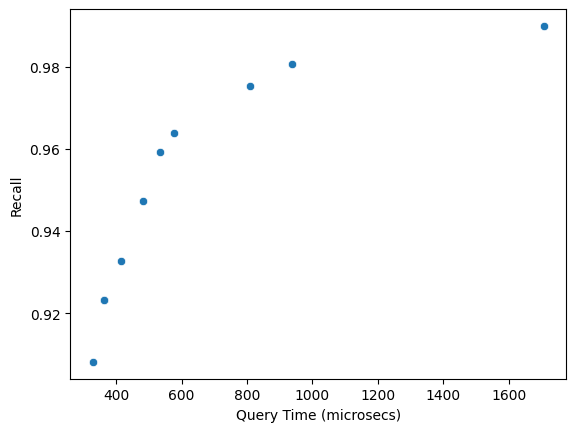

In [17]:

for mem_limit in [1.5]:
    current_df = extract_best(all_df[all_df['Memory Usage (Bytes)'] <= mem_limit * forward_index_size])

    sns.scatterplot(data=current_df, x = "Query Time (microsecs)", y="Recall")
    plt.show()

In [18]:
current_df

,Subsection,Query Time (microsecs),Recall,RR@10,Memory Usage (Bytes),Building Time (secs),name,centroid-fraction,clustering-algorithm,kmeans-doc-cut,...,max-fraction,min-cluster-size,n-postings,pruning-strategy,summary-energy,value-type,query-cut,heap-factor,knn1,first_sorted
22,combination_23,328,0.908109,0.376964,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,3,1.0,0,True
31,combination_32,364,0.923252,0.378415,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,4,1.0,0,False
30,combination_31,364,0.923252,0.378415,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,4,1.0,0,True
46,combination_47,415,0.932607,0.378621,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,6,1.0,0,True
20,combination_21,483,0.947235,0.380416,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,3,0.9,0,True
28,combination_29,534,0.959312,0.381396,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,4,0.9,0,True
36,combination_37,576,0.963825,0.381371,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,5,0.9,0,True
26,combination_27,810,0.975358,0.381821,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,4,0.8,0,True
42,combination_43,936,0.980788,0.381982,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,6,0.8,0,True
80,combination_81,1707,0.990014,0.382139,6198497884,145,building_combination_0_2025-10-03_09:52:48,0.1,random-kmeans-inverted-index-approx,15,...,4.0,10,3000,global-threshold,0.4,f16,11,0.7,0,True


In [14]:
13764389604 * 1.5

20646584406.0